# **FASE 1: Preparación de datos para predecir zonas con mayor riesgo**
**Universidad Politecnica Salesiana**
**Integrantes:** Diana Avila, Sebastian Cabrera, Valeria Mantilla, Daniel Guanga

**Proyecto:** Sistema de alerta temprana de accidentes de tránsito en Cuenca mediante una Red Neuronal Artificial.

## Objetivo de esta fase

Preparar el dataset para que el modelo aprenda patrones históricos de ocurrencia de accidentes según:

- Fecha.
- Hora.
- Parroquia.
- Zona urbana o rural.
- Feriado.

En esta arquitectura, el modelo aprenderá un **porcentaje de riesgo relativo**, calculado a partir de la frecuencia histórica de accidentes en cada combinación de lugar y momento.

> **Importante:** debido a que el dataset contiene registros de accidentes, pero no registros explícitos de “no accidente”, el valor generado es un **índice de riesgo histórico relativo**, no una probabilidad estadística absoluta de ocurrencia.


## 1. Instalación de dependencias

Ejecuta esta celda solamente si aparece un error relacionado con `openpyxl`.


In [29]:
# !pip install openpyxl

## 2. Importación de librerías

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from itertools import product

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

## 3. Carga del dataset

El archivo Excel debe estar en la misma carpeta que el notebook. Verifica que el nombre sea exactamente igual.


In [63]:
RUTA_DATASET = "Dataset_Accidentes_Cuenca_2025.xlsx"

dataframe = pd.read_excel("C:\\Users\\User\\Pictures\\Proyecto-IA\\Proyecto-IA-Siniestros-Transito\\Dataset_Accidentes_Cuenca_2025_Corregido.xlsx")

print("Dimensión original:", dataframe.shape)
dataframe.head()

Dimensión original: (1614, 14)


,FECHA,HORA,CANTON,PARROQUIA,ZONA,LATITUD_Y,LONGITUD_X,DIRECCION,TIPO_DE_SINIESTRO,CAUSA_PROBABLE,TIPO_DE_VEHICULO_1,LESIONADOS,FALLECIDOS,FERIADO
0,2024-01-01 00:00:00,15:34:59.952000,CUENCA,MOLLETURO,RURAL,-2.766635,-79.404454,RED VIAL E 582 KM 65 APROXIMADAMENTE SENTIDO ...,CHOQUE LATERAL,NO RESPETAR LAS SEÑALES REGLAMENTARIAS DE TRÁN...,AUTOMÓVIL,0,0,SI
1,2024-01-01 00:00:00,21:09:59.962000,CUENCA,SAYAUSI,RURAL,-2.802869,-79.158422,SE ENCUENTRA UBICADO RED ESTATAL E-582 SENTIDO...,PÉRDIDA DE CARRIL,CONDUCIR DESATENTO A LAS CONDICIONES DE TRÁNSI...,CAMIONETA,3,0,SI
2,2024-01-03 00:00:00,08:15:00.086000,CUENCA,TARQUI (CUENCA),RURAL,-2.974194,-79.047028,RED VIAL E 35 KM 6,PÉRDIDA DE CARRIL,CONDUCIR DESATENTO A LAS CONDICIONES DE TRÁNSI...,ESPECIAL,3,0,NO
3,2024-01-05 00:00:00,21:39:59.933000,CUENCA,BAÑOS (CUENCA),RURAL,-2.940667,-79.046417,RED VIAL E 35 KM 1.5 APROXIMADAMENTE.,CHOQUE LATERAL,NO RESPETAR LAS SEÑALES REGLAMENTARIAS DE TRÁN...,AUTOMÓVIL,0,0,NO
4,2024-01-06 00:00:00,19:59:59.971000,CUENCA,TARQUI (CUENCA),RURAL,-3.035944,-79.041639,RED VIAL E 35 KM 13 APROXIMADAMENTE.,CHOQUE POSTERIOR,NO MANTENER LA DISTANCIA PRUDENCIAL CON RESPEC...,AUTOMÓVIL,1,0,NO


## 3.1  Arreglo de datos

In [64]:

# 1. Corregir latitud positiva (olvido del signo negativo)
dataframe.loc[(dataframe['LATITUD_Y'] > 0) & (dataframe['LATITUD_Y'] < 10), 'LATITUD_Y'] = dataframe['LATITUD_Y'] * -1

# 2. Definir los límites geográficos válidos para Cuenca y alrededores
lat_min, lat_max = -3.5, -2.5
lon_min, lon_max = -79.8, -78.5

# 3. Calcular la mediana de las coordenadas correctas por Parroquia
coordenadas_validas = dataframe[(dataframe['LATITUD_Y'] >= lat_min) & (dataframe['LATITUD_Y'] <= lat_max) & 
                                (dataframe['LONGITUD_X'] >= lon_min) & (dataframe['LONGITUD_X'] <= lon_max)]
medianas_parroquia = coordenadas_validas.groupby('PARROQUIA')[['LATITUD_Y', 'LONGITUD_X']].median()

# 4. Encontrar las anomalías y reemplazarlas con la mediana de su respectiva parroquia
anomalias = dataframe[~((dataframe['LATITUD_Y'] >= lat_min) & (dataframe['LATITUD_Y'] <= lat_max) & 
                        (dataframe['LONGITUD_X'] >= lon_min) & (dataframe['LONGITUD_X'] <= lon_max))]

for index, row in anomalias.iterrows():
    parroquia = row['PARROQUIA']
    if parroquia in medianas_parroquia.index:
        dataframe.loc[index, 'LATITUD_Y'] = medianas_parroquia.loc[parroquia, 'LATITUD_Y']
        dataframe.loc[index, 'LONGITUD_X'] = medianas_parroquia.loc[parroquia, 'LONGITUD_X']

# Opcional: Exportar el Excel corregido por si quieres tenerlo de respaldo
dataframe.to_excel("Dataset_Accidentes_Cuenca_2025_Corregido.xlsx", index=False)
print(f"¡Se corrigieron {len(anomalias)} registros exitosamente!")

¡Se corrigieron 0 registros exitosamente!


In [66]:
# 5. Corrección estricta SOLO para la parroquia urbana "CUENCA"
# El área urbana de Cuenca no sale de estos límites aproximados:
lat_min_urbana, lat_max_urbana = -2.98, -2.80
lon_min_urbana, lon_max_urbana = -79.08, -78.90

# Encontrar puntos que dicen ser "CUENCA" pero están fuera de la ciudad
anomalias_urbanas = dataframe[(dataframe['PARROQUIA'] == 'CUENCA') & 
                              (~((dataframe['LATITUD_Y'] >= lat_min_urbana) & (dataframe['LATITUD_Y'] <= lat_max_urbana) & 
                                 (dataframe['LONGITUD_X'] >= lon_min_urbana) & (dataframe['LONGITUD_X'] <= lon_max_urbana)))]

# Mover esos puntos al centro urbano
for index, row in anomalias_urbanas.iterrows():
    dataframe.loc[index, 'LATITUD_Y'] = medianas_parroquia.loc['CUENCA', 'LATITUD_Y']
    dataframe.loc[index, 'LONGITUD_X'] = medianas_parroquia.loc['CUENCA', 'LONGITUD_X']

print(f"¡Se corrigieron {len(anomalias_urbanas)} anomalías urbanas adicionales!")

¡Se corrigieron 0 anomalías urbanas adicionales!


## 4. Revisión general del dataset

In [34]:
print("Columnas disponibles:")
print(dataframe.columns.tolist())

print("\nInformación general:")
dataframe.info()

Columnas disponibles:
['FECHA', 'HORA', 'CANTON', 'PARROQUIA', 'ZONA', 'LATITUD_Y', 'LONGITUD_X', 'DIRECCION', 'TIPO_DE_SINIESTRO', 'CAUSA_PROBABLE', 'TIPO_DE_VEHICULO_1', 'LESIONADOS', 'FALLECIDOS', 'FERIADO']

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1614 entries, 0 to 1613
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   FECHA               1614 non-null   object 
 1   HORA                1614 non-null   object 
 2   CANTON              1614 non-null   object 
 3   PARROQUIA           1614 non-null   object 
 4   ZONA                1614 non-null   object 
 5   LATITUD_Y           1614 non-null   float64
 6   LONGITUD_X          1614 non-null   float64
 7   DIRECCION           1614 non-null   object 
 8   TIPO_DE_SINIESTRO   1614 non-null   object 
 9   CAUSA_PROBABLE      1614 non-null   object 
 10  TIPO_DE_VEHICULO_1  1614 non-null   object 
 11  LESIONADOS        

In [35]:
print("Valores nulos por columna:")
display(dataframe.isnull().sum().to_frame("NULOS"))

Valores nulos por columna:


,NULOS
FECHA,0
HORA,0
CANTON,0
PARROQUIA,0
ZONA,0
LATITUD_Y,0
LONGITUD_X,0
DIRECCION,0
TIPO_DE_SINIESTRO,0
CAUSA_PROBABLE,0


## 5. Limpieza de nombres y variables de texto

Se eliminan espacios y se convierten las categorías a mayúsculas para evitar valores duplicados por diferencias de escritura.


In [36]:
# Limpiar nombres de columnas
dataframe.columns = (
    dataframe.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

# Limpiar columnas de texto
columnas_texto = dataframe.select_dtypes(include=["object"]).columns

for columna in columnas_texto:
    dataframe[columna] = (
        dataframe[columna]
        .astype("string")
        .str.strip()
        .str.upper()
    )

print(dataframe.columns.tolist())

['FECHA', 'HORA', 'CANTON', 'PARROQUIA', 'ZONA', 'LATITUD_Y', 'LONGITUD_X', 'DIRECCION', 'TIPO_DE_SINIESTRO', 'CAUSA_PROBABLE', 'TIPO_DE_VEHICULO_1', 'LESIONADOS', 'FALLECIDOS', 'FERIADO']


## 6. Conversión robusta de la fecha

Esta función permite interpretar fechas almacenadas como:

- Fechas normales de Excel.
- Números seriales de Excel.
- Texto.


In [37]:
def convertir_fecha(valor):
    if pd.isnull(valor):
        return pd.NaT

    # Excel puede almacenar una fecha como número serial
    if isinstance(valor, (int, float, np.integer, np.floating)):
        if valor > 20000:
            return pd.Timestamp("1899-12-30") + pd.to_timedelta(float(valor), unit="D")

    return pd.to_datetime(valor, errors="coerce")


dataframe["FECHA"] = dataframe["FECHA"].apply(convertir_fecha)

dataframe["ANIO"] = dataframe["FECHA"].dt.year
dataframe["MES"] = dataframe["FECHA"].dt.month
dataframe["DIA"] = dataframe["FECHA"].dt.day
dataframe["DIA_SEMANA"] = dataframe["FECHA"].dt.dayofweek

nombres_dias = {
    0: "LUNES",
    1: "MARTES",
    2: "MIERCOLES",
    3: "JUEVES",
    4: "VIERNES",
    5: "SABADO",
    6: "DOMINGO"
}

dataframe["NOMBRE_DIA"] = dataframe["DIA_SEMANA"].map(nombres_dias)

dataframe[["FECHA", "ANIO", "MES", "DIA", "DIA_SEMANA", "NOMBRE_DIA"]].head()

C:\Users\User\AppData\Local\Temp\ipykernel_15428\2332753224.py:10: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  return pd.to_datetime(valor, errors="coerce")


,FECHA,ANIO,MES,DIA,DIA_SEMANA,NOMBRE_DIA
0,2024-01-01,2024,1,1,0,LUNES
1,2024-01-01,2024,1,1,0,LUNES
2,2024-01-03,2024,1,3,2,MIERCOLES
3,2024-01-05,2024,1,5,4,VIERNES
4,2024-01-06,2024,1,6,5,SABADO


## 7. Conversión robusta de la hora

La hora puede venir como número decimal de Excel, texto o tipo `datetime.time`. Se convierte a:

- `HORA_DECIMAL`.
- `HORA_NUM`, entre 0 y 23.
- `RANGO_HORARIO`.


In [38]:
def convertir_hora_decimal(valor):
    if pd.isnull(valor):
        return np.nan

    # Hora como fracción de un día en Excel
    if isinstance(valor, (int, float, np.integer, np.floating)):
        numero = float(valor)

        if 0 <= numero < 1:
            return numero * 24

        if 0 <= numero <= 23:
            return numero

    # Objetos datetime/time
    if hasattr(valor, "hour"):
        minuto = getattr(valor, "minute", 0)
        segundo = getattr(valor, "second", 0)
        return valor.hour + minuto / 60 + segundo / 3600

    # Hora como texto
    texto = str(valor).strip()
    hora_convertida = pd.to_datetime(texto, errors="coerce")

    if pd.notnull(hora_convertida):
        return (
            hora_convertida.hour
            + hora_convertida.minute / 60
            + hora_convertida.second / 3600
        )

    return np.nan


dataframe["HORA_DECIMAL"] = dataframe["HORA"].apply(convertir_hora_decimal)
dataframe["HORA_NUM"] = np.floor(dataframe["HORA_DECIMAL"]).astype("Int64")


def clasificar_rango_horario(hora):
    if pd.isnull(hora):
        return pd.NA
    if 0 <= hora <= 5:
        return "MADRUGADA"
    if 6 <= hora <= 11:
        return "MANANA"
    if 12 <= hora <= 17:
        return "TARDE"
    return "NOCHE"


dataframe["RANGO_HORARIO"] = dataframe["HORA_NUM"].apply(clasificar_rango_horario)

dataframe[["HORA", "HORA_DECIMAL", "HORA_NUM", "RANGO_HORARIO"]].head()

,HORA,HORA_DECIMAL,HORA_NUM,RANGO_HORARIO
0,15:34:59.952000,15.583056,15,TARDE
1,21:09:59.962000,21.166389,21,NOCHE
2,08:15:00.086000,8.250000,8,MANANA
3,21:39:59.933000,21.666389,21,NOCHE
4,19:59:59.971000,19.999722,19,NOCHE


In [39]:
import numpy as np

# Transformación cíclica para la HORA (24 horas)
dataframe['HORA_SIN'] = np.sin(2 * np.pi * dataframe['HORA_NUM'].astype(float) / 24.0)
dataframe['HORA_COS'] = np.cos(2 * np.pi * dataframe['HORA_NUM'].astype(float) / 24.0)

# Transformación cíclica para el DÍA DE LA SEMANA (7 días)
dataframe['DIA_SIN'] = np.sin(2 * np.pi * dataframe['DIA_SEMANA'] / 7.0)
dataframe['DIA_COS'] = np.cos(2 * np.pi * dataframe['DIA_SEMANA'] / 7.0)

## 8. Normalización de la variable FERIADO

La variable se normaliza a las categorías `SI` y `NO`.


In [40]:
dataframe["FERIADO"] = (
    dataframe["FERIADO"]
    .astype("string")
    .str.strip()
    .str.upper()
    .replace({
        "SÍ": "SI",
        "1": "SI",
        "TRUE": "SI",
        "0": "NO",
        "FALSE": "NO"
    })
)

print(dataframe["FERIADO"].value_counts(dropna=False))

FERIADO
NO    1461
SI     153
Name: count, dtype: Int64


## 9. Conversión de lesionados y fallecidos

Estas variables no serán entradas del modelo de riesgo. Se conservarán para mostrar indicadores históricos en Power BI o en la aplicación web.


In [41]:
for columna in ["LESIONADOS", "FALLECIDOS"]:
    dataframe[columna] = (
        pd.to_numeric(dataframe[columna], errors="coerce")
        .fillna(0)
        .clip(lower=0)
    )

dataframe["TOTAL_VICTIMAS"] = (
    dataframe["LESIONADOS"] + dataframe["FALLECIDOS"]
)

dataframe[["LESIONADOS", "FALLECIDOS", "TOTAL_VICTIMAS"]].head()

,LESIONADOS,FALLECIDOS,TOTAL_VICTIMAS
0,0,0,0
1,3,0,3
2,3,0,3
3,0,0,0
4,1,0,1


## 10. Eliminación de registros incompletos para el modelo

Para crear el índice de riesgo se requieren los campos principales de ubicación y tiempo.


In [42]:
columnas_obligatorias = [
    "MES",
    "DIA_SEMANA",
    "HORA_NUM",
    "RANGO_HORARIO",
    "PARROQUIA",
    "ZONA",
    "FERIADO"
]

antes = len(dataframe)

dataframe_modelable = dataframe.dropna(
    subset=columnas_obligatorias
).copy()

despues = len(dataframe_modelable)

print("Registros originales:", antes)
print("Registros utilizables:", despues)
print("Registros eliminados:", antes - despues)

Registros originales: 1614
Registros utilizables: 1614
Registros eliminados: 0


## 11. Construcción de la frecuencia histórica de accidentes

Se agrupan los registros por:

- Mes.
- Día de la semana.
- Hora.
- Rango horario.
- Parroquia.
- Zona.
- Feriado.

La cantidad de filas en cada grupo corresponde al número histórico de accidentes para esa combinación.


In [43]:
columnas_agrupacion = [
    "MES",
    "DIA_SEMANA",
    "RANGO_HORARIO",
    "PARROQUIA",
    "ZONA",
    "FERIADO"
]

frecuencia_observada = (
    dataframe_modelable
    .groupby(columnas_agrupacion, dropna=False)
    .size()
    .reset_index(name="NUM_ACCIDENTES")
)

print("Combinaciones con accidentes:", len(frecuencia_observada))
frecuencia_observada.sort_values("NUM_ACCIDENTES", ascending=False).head(10)

Combinaciones con accidentes: 870


,MES,DIA_SEMANA,RANGO_HORARIO,PARROQUIA,ZONA,FERIADO,NUM_ACCIDENTES
610,9,5,NOCHE,CUENCA,URBANA,NO,11
558,9,0,MANANA,CUENCA,URBANA,NO,11
588,9,2,TARDE,CUENCA,URBANA,NO,10
458,7,4,NOCHE,CUENCA,URBANA,NO,9
593,9,3,TARDE,CUENCA,URBANA,NO,9
518,8,3,NOCHE,CUENCA,URBANA,NO,9
561,9,0,NOCHE,CUENCA,URBANA,NO,9
107,2,5,NOCHE,CUENCA,URBANA,NO,9
666,10,3,MANANA,CUENCA,URBANA,NO,8
438,7,2,MANANA,CUENCA,URBANA,NO,8


## 12. Creación de combinaciones sin accidentes registrados

El dataset original contiene únicamente eventos donde ocurrió un accidente. Para que el modelo también conozca escenarios con frecuencia cero, se crea una cuadrícula de combinaciones posibles usando:

- Meses observados.
- Días de la semana.
- Horas.
- Pares válidos de parroquia y zona.
- Valores de feriado.

Las combinaciones sin registros históricos reciben `NUM_ACCIDENTES = 0`.


In [44]:
dataset_riesgo = dataframe_modelable.merge(
    frecuencia_observada,
    on=columnas_agrupacion,
    how="left"
)

print("Registros reales usados para el modelo:", len(dataset_riesgo))

dataset_riesgo[
    columnas_agrupacion + ["NUM_ACCIDENTES"]
].head()

max_accidentes = dataset_riesgo["NUM_ACCIDENTES"].max()

dataset_riesgo["RIESGO_PORCENTAJE"] = (
    dataset_riesgo["NUM_ACCIDENTES"]
    / max_accidentes
    * 100
).round(2)


def clasificar_nivel_riesgo(porcentaje):
    if porcentaje >= 70:
        return "ALTO"
    elif porcentaje >= 40:
        return "MEDIO"
    else:
        return "BAJO"

dataset_riesgo["NIVEL_RIESGO"] = (
    dataset_riesgo["RIESGO_PORCENTAJE"]
    .apply(clasificar_nivel_riesgo)
)


Registros reales usados para el modelo: 1614


## 13. Creación del porcentaje de riesgo relativo

Se toma como referencia la combinación histórica con mayor número de accidentes:

\[
Riesgo\ relativo = 
rac{	ext{Accidentes de la combinación}}
{	ext{Máximo de accidentes observado}} 	imes 100
\]

Interpretación:

- `0 %`: no existen accidentes registrados para esa combinación.
- `100 %`: corresponde a la combinación con mayor frecuencia histórica.
- Los demás valores indican riesgo relativo respecto al máximo observado.

Este indicador no debe presentarse como probabilidad absoluta.


In [45]:
max_accidentes = dataset_riesgo["NUM_ACCIDENTES"].max()

if max_accidentes <= 0:
    raise ValueError("No se encontraron accidentes para calcular el riesgo.")

dataset_riesgo["RIESGO_PORCENTAJE"] = (
    dataset_riesgo["NUM_ACCIDENTES"] / max_accidentes * 100
).round(2)

def clasificar_nivel_riesgo(porcentaje):
    if porcentaje >= 70:
        return "ALTO"
    if porcentaje >= 40:
        return "MEDIO"
    return "BAJO"

dataset_riesgo["NIVEL_RIESGO"] = (
    dataset_riesgo["RIESGO_PORCENTAJE"]
    .apply(clasificar_nivel_riesgo)
)

print("Máximo histórico de accidentes por combinación:", max_accidentes)
display(
    dataset_riesgo[
        ["NUM_ACCIDENTES", "RIESGO_PORCENTAJE"]
    ].describe()
)
display(
    dataset_riesgo["NIVEL_RIESGO"]
    .value_counts()
    .to_frame("CANTIDAD")
)


Máximo histórico de accidentes por combinación: 11


,NUM_ACCIDENTES,RIESGO_PORCENTAJE
count,1614.000000,1614.000000
mean,3.287485,29.884913
std,2.481751,22.562048
min,1.000000,9.090000
25%,1.000000,9.090000
50%,3.000000,27.270000
75%,5.000000,45.450000
max,11.000000,100.000000


,CANTIDAD
NIVEL_RIESGO,
BAJO,1123
MEDIO,358
ALTO,133


## 14. Distribución de los niveles de riesgo

C:\Users\User\AppData\Local\Temp\ipykernel_15428\2236864998.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


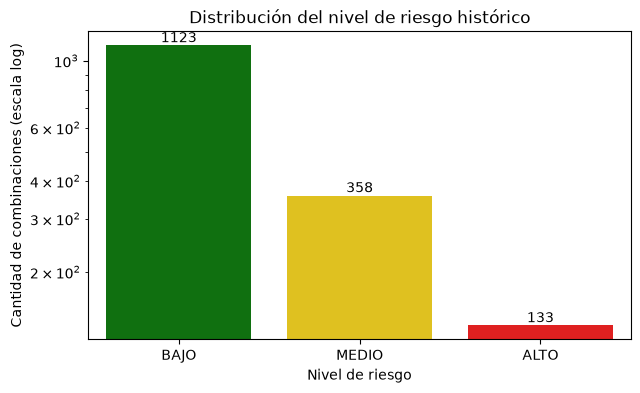

In [46]:
# Distribución Escala logarítmica

plt.figure(figsize=(7,4))

ax = sns.countplot(
    data=dataset_riesgo,
    x="NIVEL_RIESGO",
    order=["BAJO","MEDIO","ALTO"],
    palette=["green","gold","red"]
)

plt.yscale("log")

plt.title("Distribución del nivel de riesgo histórico")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Cantidad de combinaciones (escala log)")

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()



## 15. Tabla histórica para indicadores y Power BI

La red neuronal predecirá solamente el riesgo. Las otras salidas se obtendrán consultando la información histórica.

Para cada combinación se calculan:

- Causa más frecuente.
- Tipo de siniestro más frecuente.
- Tipo de vehículo más frecuente.
- Promedio de lesionados.
- Promedio de fallecidos.
- Promedio de víctimas.
- Coordenadas promedio.


In [47]:
def moda_segura(serie):
    serie_limpia = serie.dropna()

    if serie_limpia.empty:
        return pd.NA

    modas = serie_limpia.mode()
    return modas.iloc[0] if not modas.empty else pd.NA


resumen_historico = (
    dataframe_modelable
    .groupby(columnas_agrupacion, dropna=False)
    .agg(
        NUM_ACCIDENTES=("PARROQUIA", "size"),
        CAUSA_MAS_FRECUENTE=("CAUSA_PROBABLE", moda_segura),
        SINIESTRO_MAS_FRECUENTE=("TIPO_DE_SINIESTRO", moda_segura),
        VEHICULO_MAS_FRECUENTE=("TIPO_DE_VEHICULO_1", moda_segura),
        PROMEDIO_LESIONADOS=("LESIONADOS", "mean"),
        PROMEDIO_FALLECIDOS=("FALLECIDOS", "mean"),
        PROMEDIO_VICTIMAS=("TOTAL_VICTIMAS", "mean"),
        LATITUD_PROMEDIO=("LATITUD_Y", "mean"),
        LONGITUD_PROMEDIO=("LONGITUD_X", "mean")
    )
    .reset_index()
)

resumen_historico["PROMEDIO_LESIONADOS"] = (
    resumen_historico["PROMEDIO_LESIONADOS"].round(2)
)
resumen_historico["PROMEDIO_FALLECIDOS"] = (
    resumen_historico["PROMEDIO_FALLECIDOS"].round(2)
)
resumen_historico["PROMEDIO_VICTIMAS"] = (
    resumen_historico["PROMEDIO_VICTIMAS"].round(2)
)

resumen_historico.head()

,MES,DIA_SEMANA,RANGO_HORARIO,PARROQUIA,ZONA,FERIADO,NUM_ACCIDENTES,CAUSA_MAS_FRECUENTE,SINIESTRO_MAS_FRECUENTE,VEHICULO_MAS_FRECUENTE,PROMEDIO_LESIONADOS,PROMEDIO_FALLECIDOS,PROMEDIO_VICTIMAS,LATITUD_PROMEDIO,LONGITUD_PROMEDIO
0,1,0,MADRUGADA,CUENCA,URBANA,SI,2,"CONDUCE BAJO LA INFLUENCIA DE ALCOHOL, SUSTANC...",CHOQUE POSTERIOR,MOTOCICLETA,0.50,0.0,0.50,-2.904572,-78.979707
1,1,0,MANANA,CUENCA,URBANA,NO,2,CONDUCIR DESATENTO A LAS CONDICIONES DE TRÁNSI...,ATROPELLOS,AUTOMÓVIL,1.00,0.0,1.00,-2.907090,-78.999710
2,1,0,MANANA,CUENCA,URBANA,SI,1,CONDUCIR DESATENTO A LAS CONDICIONES DE TRÁNSI...,PÉRDIDA DE CARRIL,AUTOMÓVIL,0.00,0.0,0.00,-2.919688,-79.004881
3,1,0,MANANA,VALLE,RURAL,NO,1,CONDUCIR DESATENTO A LAS CONDICIONES DE TRÁNSI...,PÉRDIDA DE PISTA,AUTOMÓVIL,1.00,0.0,1.00,-2.930489,-78.967382
4,1,0,NOCHE,CUENCA,URBANA,NO,3,"CONDUCE BAJO LA INFLUENCIA DE ALCOHOL, SUSTANC...",CHOQUE LATERAL,AUTOMÓVIL,1.33,0.0,1.33,-2.891137,-78.986230


## 16. Selección de variables de entrada y salida

### Entradas del modelo

- `MES`
- `DIA_SEMANA`
- `HORA_NUM`
- `RANGO_HORARIO`
- `PARROQUIA`
- `ZONA`
- `FERIADO`

### Salida del modelo

- `RIESGO_PORCENTAJE`

La clasificación `BAJO`, `MEDIO` o `ALTO` se realizará después, aplicando los umbrales definidos al porcentaje predicho.


In [48]:
columnas_entrada = [
    "MES",
    "DIA_SIN",
    "DIA_COS",
    "HORA_SIN",
    "HORA_COS",
    "RANGO_HORARIO",
    "PARROQUIA",
    "ZONA",
    "FERIADO"
]

X = dataset_riesgo[columnas_entrada].copy()
Y = dataset_riesgo["RIESGO_PORCENTAJE"].astype(float).copy()

print("Dimensión de X:", X.shape)
print("Dimensión de Y:", Y.shape)

display(X.head())
display(Y.head())

Dimensión de X: (1614, 9)
Dimensión de Y: (1614,)


,MES,DIA_SIN,DIA_COS,HORA_SIN,HORA_COS,RANGO_HORARIO,PARROQUIA,ZONA,FERIADO
0,1,0.000000,1.000000,-0.707107,-0.707107,TARDE,MOLLETURO,RURAL,SI
1,1,0.000000,1.000000,-0.707107,0.707107,NOCHE,SAYAUSI,RURAL,SI
2,1,0.974928,-0.222521,0.866025,-0.500000,MANANA,TARQUI (CUENCA),RURAL,NO
3,1,-0.433884,-0.900969,-0.707107,0.707107,NOCHE,BAÑOS (CUENCA),RURAL,NO
4,1,-0.974928,-0.222521,-0.965926,0.258819,NOCHE,TARQUI (CUENCA),RURAL,NO


0    9.09
1    9.09
2    9.09
3    9.09
4    9.09
Name: RIESGO_PORCENTAJE, dtype: float64

## 17. Separación de variables numéricas y categóricas

In [49]:
variables_numericas = [
    "MES",
    "DIA_SIN",
    "DIA_COS",
    "HORA_SIN",
    "HORA_COS"
]

variables_categoricas = [
    "RANGO_HORARIO",
    "PARROQUIA",
    "ZONA",
    "FERIADO"
]

print("Variables numéricas:", variables_numericas)
print("Variables categóricas:", variables_categoricas)

Variables numéricas: ['MES', 'DIA_SIN', 'DIA_COS', 'HORA_SIN', 'HORA_COS']
Variables categóricas: ['RANGO_HORARIO', 'PARROQUIA', 'ZONA', 'FERIADO']


## 18. Construcción del preprocesamiento

Las variables numéricas se imputan y estandarizan. Las variables categóricas se imputan y convierten mediante One-Hot Encoding.


In [50]:
transformador_numerico = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

transformador_categorico = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocesador = ColumnTransformer(
    transformers=[
        ("num", transformador_numerico, variables_numericas),
        ("cat", transformador_categorico, variables_categoricas)
    ]
)

## 19. División del dataset en entrenamiento y prueba

Se reserva el 20 % para evaluar el modelo en la Fase 2.


In [51]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Y_train:", Y_train.shape)
print("Y_test:", Y_test.shape)

X_train: (1291, 9)
X_test: (323, 9)
Y_train: (1291,)
Y_test: (323,)


## 20. Aplicación del preprocesamiento

El preprocesador se ajusta únicamente con el conjunto de entrenamiento para evitar fuga de información.


In [52]:
X_train_transformado = preprocesador.fit_transform(X_train)
X_test_transformado = preprocesador.transform(X_test)

print("X_train transformado:", X_train_transformado.shape)
print("X_test transformado:", X_test_transformado.shape)

print("\nTipo X_train transformado:", type(X_train_transformado))
print("Tipo Y_train:", type(Y_train))

X_train transformado: (1291, 35)
X_test transformado: (323, 35)

Tipo X_train transformado: <class 'numpy.ndarray'>
Tipo Y_train: <class 'pandas.core.series.Series'>


## 21. Guardado de resultados para la Fase 2

La Fase 2 será un notebook independiente. Por eso se guardan todos los objetos necesarios en un archivo `.pkl`.


In [53]:
datos_fase1 = {
    "X_train_transformado": X_train_transformado,
    "X_test_transformado": X_test_transformado,
    "Y_train": Y_train.to_numpy(dtype=float),
    "Y_test": Y_test.to_numpy(dtype=float),
    "preprocesador": preprocesador,
    "columnas_entrada": columnas_entrada,
    "variables_numericas": variables_numericas,
    "variables_categoricas": variables_categoricas,
    "max_accidentes": int(max_accidentes)
}

with open("datos_fase1_riesgo_ubicacion.pkl", "wb") as archivo:
    pickle.dump(datos_fase1, archivo)

print("Archivo guardado: datos_fase1_riesgo_ubicacion.pkl")
print("Claves guardadas:")
print(datos_fase1.keys())

Archivo guardado: datos_fase1_riesgo_ubicacion.pkl
Claves guardadas:
dict_keys(['X_train_transformado', 'X_test_transformado', 'Y_train', 'Y_test', 'preprocesador', 'columnas_entrada', 'variables_numericas', 'variables_categoricas', 'max_accidentes'])


## 22. Exportación de tablas auxiliares

Se exportan dos archivos:

1. `dataset_modelo_riesgo.csv`: datos agregados usados por el modelo.
2. `resumen_historico_powerbi.csv`: indicadores históricos para Power BI o la aplicación web.
3. `accidentes_limpios_powerbi.csv`: registros individuales con campos transformados para construir el mapa.


In [54]:
dataset_riesgo.to_csv(
    "dataset_modelo_riesgo.csv",
    index=False,
    encoding="utf-8-sig",
    sep=";",
    decimal="," 
)

resumen_historico.to_csv(
    "resumen_historico_powerbi.csv",
    index=False,
    encoding="utf-8-sig",
    sep=";",
    decimal="," 
)

dataframe_modelable.to_csv(
    "accidentes_limpios_powerbi.csv",
    index=False,
    encoding="utf-8-sig",
    sep=";",
    decimal="," 
)

print("Archivos CSV guardados correctamente con separador ';' y coma decimal.")

Archivos CSV guardados correctamente con separador ';' y coma decimal.


## 23. Ejemplo de entrada para la futura predicción

El usuario ingresará una fecha, una hora, una parroquia y una zona. El sistema derivará automáticamente las demás variables.


In [55]:
fecha_ejemplo = pd.Timestamp("2025-07-15")
hora_ejemplo = 18
parroquia_ejemplo = "EL VECINO"
zona_ejemplo = "URBANA"
feriado_ejemplo = "NO"

nuevo_ejemplo = pd.DataFrame({
    "MES": [fecha_ejemplo.month],
    "DIA_SIN": [np.sin(2 * np.pi * fecha_ejemplo.dayofweek / 7.0)],
    "DIA_COS": [np.cos(2 * np.pi * fecha_ejemplo.dayofweek / 7.0)],
    "HORA_SIN": [np.sin(2 * np.pi * hora_ejemplo / 24.0)],
    "HORA_COS": [np.cos(2 * np.pi * hora_ejemplo / 24.0)],
    "RANGO_HORARIO": [clasificar_rango_horario(hora_ejemplo)],
    "PARROQUIA": [parroquia_ejemplo],
    "ZONA": [zona_ejemplo],
    "FERIADO": [feriado_ejemplo]
})

nuevo_ejemplo_transformado = preprocesador.transform(nuevo_ejemplo)

display(nuevo_ejemplo)
print("Dimensión transformada:", nuevo_ejemplo_transformado.shape)

,MES,DIA_SIN,DIA_COS,HORA_SIN,HORA_COS,RANGO_HORARIO,PARROQUIA,ZONA,FERIADO
0,7,0.781831,0.62349,-1.0,-1.836970e-16,NOCHE,EL VECINO,URBANA,NO


Dimensión transformada: (1, 35)


## 24. Resumen de la Fase 1

En esta fase se realizó:

1. Carga y limpieza del dataset.
2. Conversión robusta de fecha y hora.
3. Creación de mes, día de la semana, hora y rango horario.
4. Normalización de parroquia, zona y feriado.
5. Cálculo de frecuencias históricas de accidentes por lugar y momento.
6. Inclusión de combinaciones sin accidentes registrados.
7. Creación del porcentaje de riesgo relativo.
8. Creación de los niveles de riesgo:
   - Bajo: 0–39 %.
   - Medio: 40–69 %.
   - Alto: 70–100 %.
9. Creación de una tabla histórica para Power BI.
10. Selección y transformación de variables.
11. División en entrenamiento y prueba.
12. Guardado de los datos para la Fase 2.

La Fase 2 deberá entrenar una **red neuronal de regresión**, porque la salida será un porcentaje continuo entre 0 y 100.
